# Ethiopia EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## Load

In [2]:
df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## Clean

In [3]:
df.replace(-999, np.nan, inplace=True)
df = df.drop_duplicates()
print(df.describe())

missing_pct = df.isna().mean() * 100
print(missing_pct[missing_pct > 0])


              YEAR          DOY         T2M      T2M_MAX      T2M_MIN  \
count  4108.000000  4108.000000  4108.00000  4108.000000  4108.000000   
mean   2020.131451   180.121227    16.06850    23.199175    10.227544   
min    2015.000000     1.000000    10.03000    15.650000     1.170000   
25%    2017.000000    86.000000    14.82000    21.110000     8.417500   
50%    2020.000000   179.000000    16.04000    22.740000    10.990000   
75%    2023.000000   272.000000    17.36000    25.170000    12.220000   
max    2026.000000   366.000000    21.53000    30.930000    15.680000   
std       3.248907   106.294767     1.89805     2.751471     2.607256   

         T2M_RANGE  PRECTOTCORR         RH2M         WS2M     WS2M_MAX  \
count  4108.000000  4108.000000  4108.000000  4108.000000  4108.000000   
mean     12.971631     3.633795    68.408588     1.979998     3.575246   
min       3.560000     0.000000    14.420000     0.460000     0.790000   
25%       9.830000     0.020000    59.030000  

## Outliers

In [4]:
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z = np.abs(stats.zscore(df[weather_cols].dropna(), nan_policy='omit'))
z_df = pd.DataFrame(z, index=df[weather_cols].dropna().index, columns=weather_cols)
print((z_df > 3).sum())

df = df[df.isna().mean(axis=1) <= 0.3].copy()
df[weather_cols] = df[weather_cols].ffill().bfill()

if 'T2M_RANGE' not in df.columns:
        df['T2M_RANGE'] = df['T2M_MAX'] - df['T2M_MIN']
        
df.to_csv('../data/ethiopia_clean.csv', index=False)
print('saved')


T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64
saved


## Time series

C:\Users\HP\AppData\Local\Temp\ipykernel_5352\2426191139.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df.set_index('Date').resample('M')['T2M'].mean().dropna()


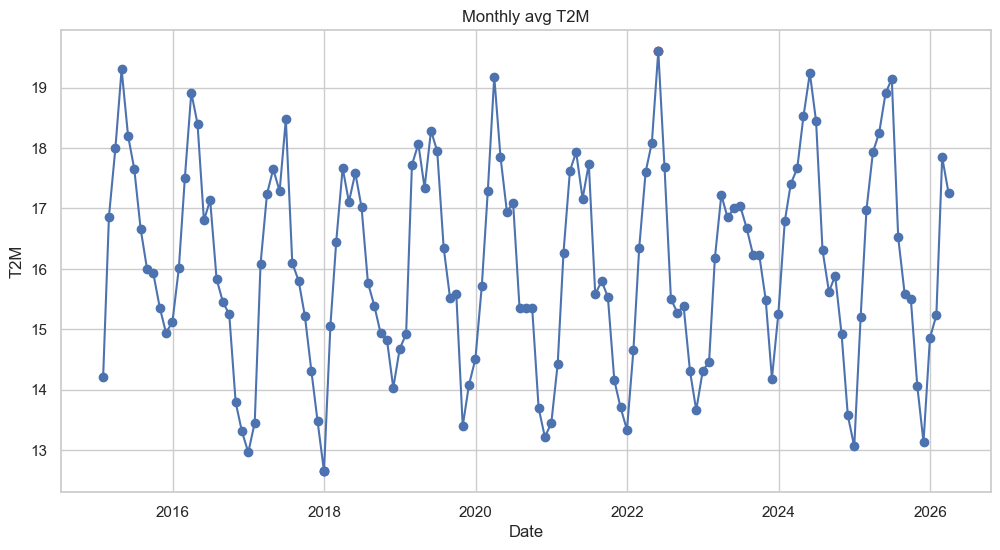

In [5]:
monthly_temp = df.set_index('Date').resample('M')['T2M'].mean().dropna()
warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

plt.figure()
plt.plot(monthly_temp.index, monthly_temp.values, marker='o')
plt.title('Monthly avg T2M')
plt.xlabel('Date')
plt.ylabel('T2M')
plt.scatter([warmest], [monthly_temp.loc[warmest]], color='red')
plt.scatter([coolest], [monthly_temp.loc[coolest]], color='blue')
plt.show()


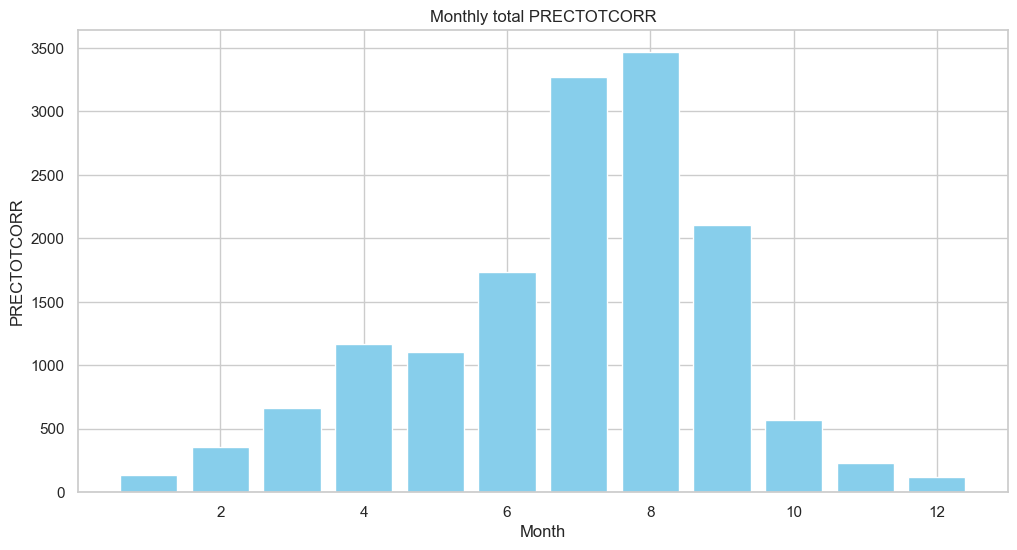

In [6]:

monthly_precip = df.groupby('Month')['PRECTOTCORR'].sum()
plt.figure()
plt.bar(monthly_precip.index, monthly_precip.values, color='skyblue')
plt.title('Monthly total PRECTOTCORR')
plt.xlabel('Month')
plt.ylabel('PRECTOTCORR')
plt.show()



## Correlation

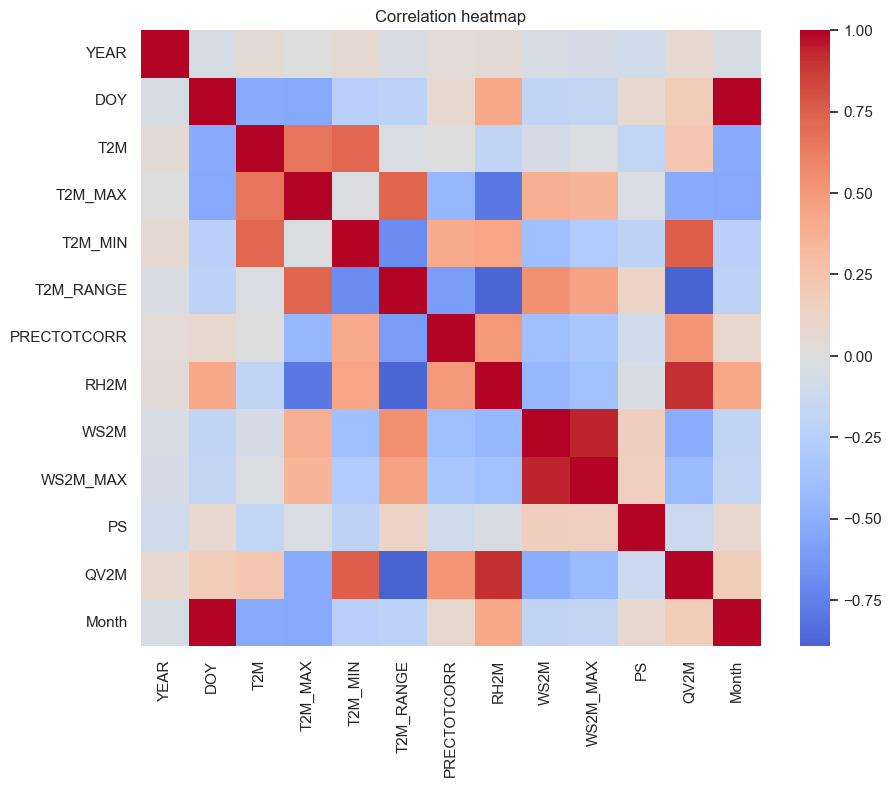

In [7]:
num = df.select_dtypes(include=[np.number])
corr = num.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation heatmap')
plt.show()

DOY       Month    0.996557
Month     DOY      0.996557
WS2M_MAX  WS2M     0.940826
dtype: float64


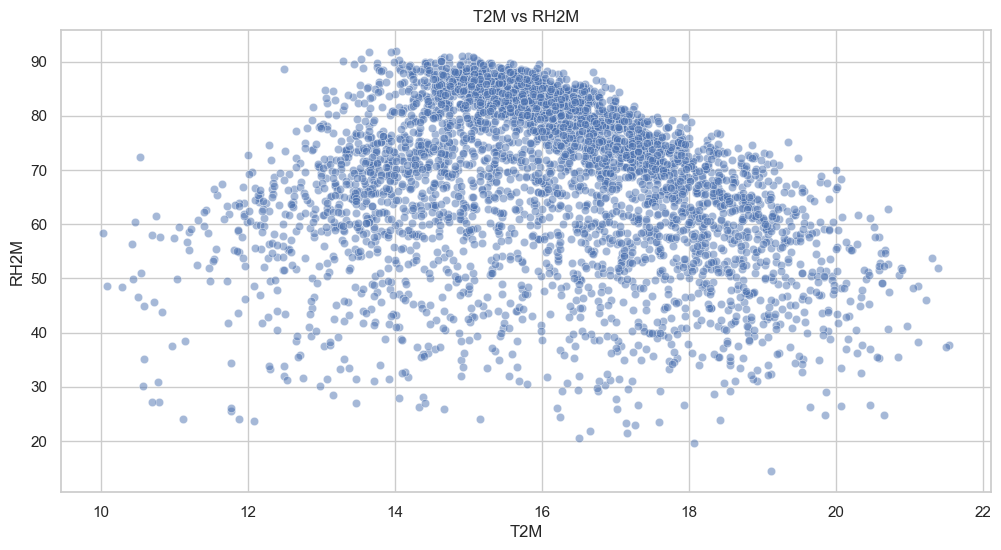

In [8]:

print(corr.unstack().sort_values(ascending=False)[len(corr):len(corr)+3])
plt.figure()
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5)
plt.title('T2M vs RH2M')
plt.show()

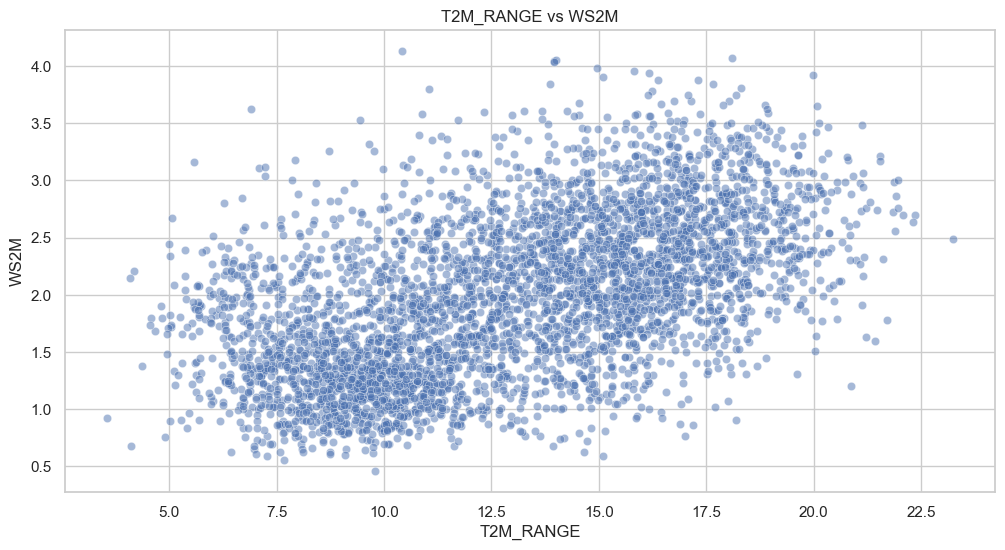

In [9]:

plt.figure()
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.5)
plt.title('T2M_RANGE vs WS2M')
plt.show()


## Distribution

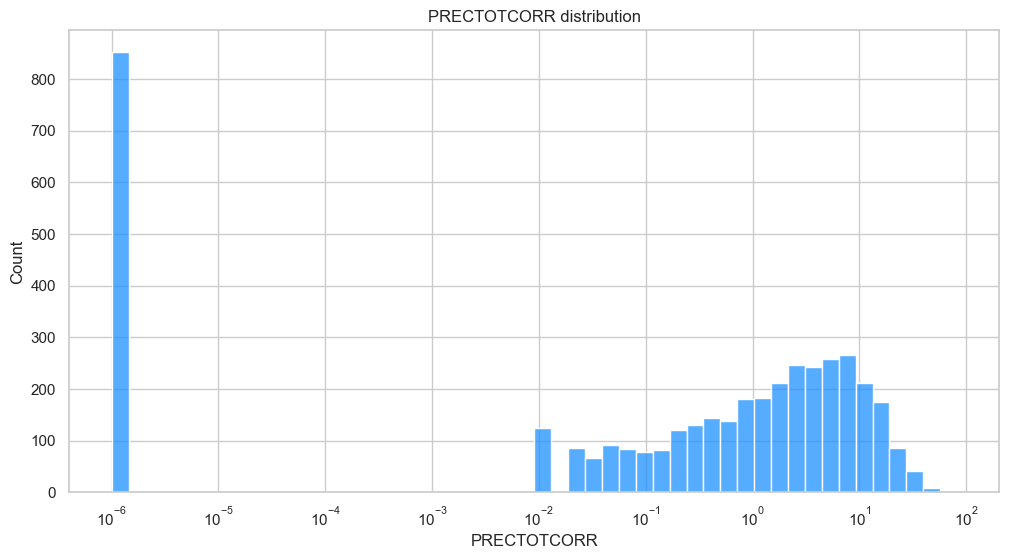

In [10]:
plt.figure()
sns.histplot(df['PRECTOTCORR'].fillna(0) + 1e-6, bins=50, log_scale=True, color='dodgerblue')
plt.title('PRECTOTCORR distribution')
plt.show()


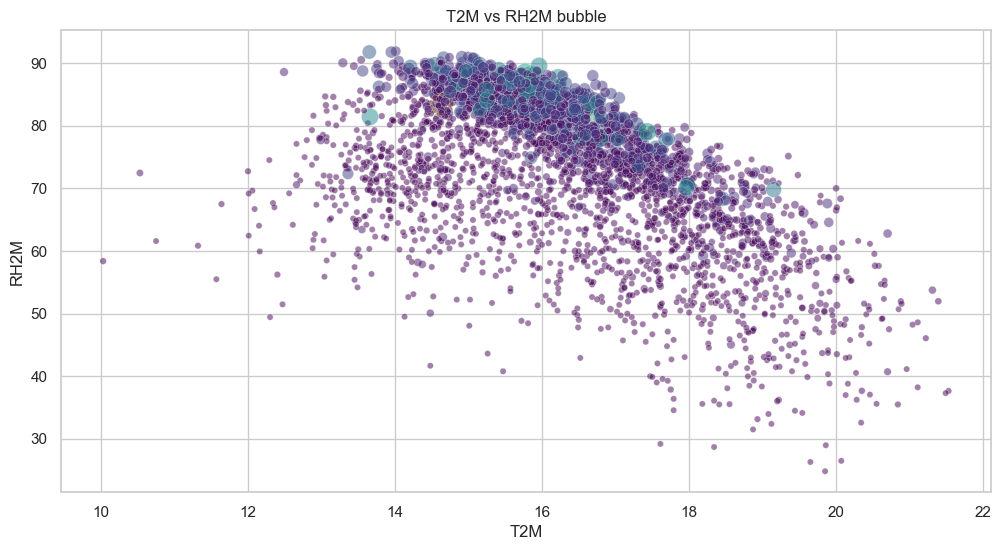

In [11]:
plt.figure()
df2 = df[df['PRECTOTCORR'] > 0]
sns.scatterplot(data=df2, x='T2M', y='RH2M', size='PRECTOTCORR', sizes=(20, 300), alpha=0.5, hue='PRECTOTCORR', palette='viridis', legend=False)
plt.title('T2M vs RH2M bubble')
plt.show()